# Error Analysis: the gender baseline

Where the control model is wrong, and how much is available in each pocket. This is the map for
deciding what to build next -- a feature is only worth adding if it can move rows in one of these
groups.

Predictions are out-of-fold: every row is predicted by a model that never saw it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

from preprocessing import build_preprocessing_pipeline
from train import MODELS

df = pd.read_csv("data/train.csv")
X, y = df.drop(columns=["Survived"]), df["Survived"]

# built from the config rather than hand-rolled, so this notebook can't drift from what
# `train gender_baseline` actually runs
config = yaml.safe_load(open("configs/gender_baseline.yaml"))
baseline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(config.get("features", []))),
    ("model", MODELS[config["model"]](**config.get("params", {}))),
])
config

{'model': 'decision_stump',
 'features': [],
 'params': {'max_depth': 1, 'random_state': 42}}

In [2]:
# out-of-fold predictions, repeated. cross_val_predict can't take a repeated splitter (a row
# would land in several test folds), so the repeats are run by hand and the results stacked
REPEATS = 10
oof = pd.DataFrame(index=X.index, columns=range(REPEATS), dtype=int)

for repeat in range(REPEATS):
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=repeat)
    for train_idx, test_idx in folds.split(X, y):
        fitted = baseline.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof.iloc[test_idx, repeat] = fitted.predict(X.iloc[test_idx])

# a depth-1 tree on this data splits on Sex in every fold, so the out-of-fold predictions should
# reproduce the plain rule exactly. worth asserting rather than assuming
gender_rule = (X["Sex"] == "female").astype(int).to_numpy()
identical = all((oof[r].to_numpy() == gender_rule).all() for r in range(REPEATS))
print("OOF predictions identical to 'all women survive', every repeat:", identical)
print(f"OOF accuracy: {(oof[0] == y).mean():.4f}")

OOF predictions identical to 'all women survive', every repeat: True
OOF accuracy: 0.7868


In [3]:
# one row per Sex x Pclass pocket
groups = pd.DataFrame({
    "Sex": X["Sex"],
    "Pclass": X["Pclass"],
    "predicted": oof[0],
    "actual": y,
})
groups["correct"] = groups["predicted"] == groups["actual"]
groups["group"] = groups["Sex"] + " " + groups["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})

summary = groups.groupby("group").agg(
    n=("correct", "size"),
    correct=("correct", "sum"),
    predicted=("predicted", "first"),
).assign(wrong=lambda d: d["n"] - d["correct"])
summary["accuracy"] = summary["correct"] / summary["n"]
summary["share_of_all_errors"] = summary["wrong"] / summary["wrong"].sum()
summary = summary.sort_values("wrong", ascending=False)
summary[["n", "predicted", "correct", "wrong", "accuracy", "share_of_all_errors"]].round(3)

,n,predicted,correct,wrong,accuracy,share_of_all_errors
group,,,,,,
female 3rd,144,1.0,72,72,0.500,0.379
male 3rd,347,0.0,300,47,0.865,0.247
male 1st,122,0.0,77,45,0.631,0.237
male 2nd,108,0.0,91,17,0.843,0.089
female 2nd,76,1.0,70,6,0.921,0.032
female 1st,94,1.0,91,3,0.968,0.016


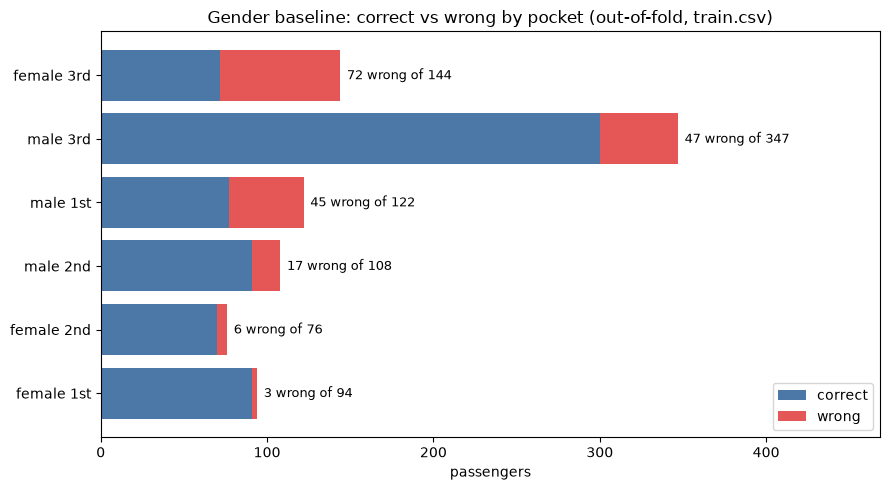

In [4]:
# the chart: how many rows in each pocket the rule gets right and wrong
plot_order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_order, summary["correct"], color="#4c78a8", label="correct")
ax.barh(plot_order, summary["wrong"], left=summary["correct"], color="#e45756", label="wrong")
for i, row in enumerate(summary.itertuples()):
    ax.text(row.n + 4, i, f"{row.wrong} wrong of {row.n}", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, summary["n"].max() * 1.35)
ax.set_xlabel("passengers")
ax.set_title("Gender baseline: correct vs wrong by pocket (out-of-fold, train.csv)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [5]:
# what each pocket is actually worth. the rule already scores `accuracy` here, so a replacement
# only gains rows once it beats that -- net = new_accuracy * n - correct. negative numbers mean a
# predictor at that accuracy would be worse than leaving the pocket alone
gain = summary.copy()
gain["rule_accuracy"] = gain["accuracy"]
for target in (0.70, 0.80, 0.90, 1.00):
    gain[f"net@{target:.0%}"] = (target * gain["n"]).round(0) - gain["correct"]

print("+14 net rows on the 418-row test set is 0.80 on the leaderboard;")
print("scaled to these 891 rows that is about +30.\n")
gain[["n", "wrong", "rule_accuracy", "net@70%", "net@80%", "net@90%", "net@100%"]].round(3)

+14 net rows on the 418-row test set is 0.80 on the leaderboard;
scaled to these 891 rows that is about +30.



,n,wrong,rule_accuracy,net@70%,net@80%,net@90%,net@100%
group,,,,,,,
female 3rd,144,72,0.500,29.0,43.0,58.0,72.0
male 3rd,347,47,0.865,-57.0,-22.0,12.0,47.0
male 1st,122,45,0.631,8.0,21.0,33.0,45.0
male 2nd,108,17,0.843,-15.0,-5.0,6.0,17.0
female 2nd,76,6,0.921,-17.0,-9.0,-2.0,6.0
female 1st,94,3,0.968,-25.0,-16.0,-6.0,3.0


## Comparison: baseline vs baseline + the family exception

`gender_plus_family` is the same rule with one carve-out -- 3rd-class women in a family of 5+ are
predicted to die. Out-of-fold, pocket by pocket, here is what that bought and what it cost.

In [6]:
# out-of-fold predictions for any config, so the two are measured identically
def out_of_fold(config_name, seed=42):
    cfg = yaml.safe_load(open(f"configs/{config_name}.yaml"))
    pipe = Pipeline([
        ("preprocessing", build_preprocessing_pipeline(cfg.get("features", []))),
        ("model", MODELS[cfg["model"]](**cfg.get("params", {}))),
    ])
    predictions = pd.Series(index=X.index, dtype=int)
    for train_idx, test_idx in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y):
        predictions.iloc[test_idx] = pipe.fit(X.iloc[train_idx], y.iloc[train_idx]).predict(X.iloc[test_idx])
    return predictions


CONFIGS = ["gender_baseline", "gender_plus_family"]
predictions = {name: out_of_fold(name) for name in CONFIGS}

comparison = pd.DataFrame(index=summary.index)
for name in CONFIGS:
    hit = predictions[name] == y
    comparison[f"{name}_correct"] = hit.groupby(groups["group"]).sum()
    comparison[f"{name}_wrong"] = (~hit).groupby(groups["group"]).sum()
comparison["n"] = summary["n"]
comparison["net_rows"] = comparison["gender_plus_family_correct"] - comparison["gender_baseline_correct"]
comparison = comparison.loc[summary.index]
comparison

,gender_baseline_correct,gender_baseline_wrong,gender_plus_family_correct,gender_plus_family_wrong,n,net_rows
group,,,,,,
female 3rd,72,72,91,53,144,19
male 3rd,300,47,299,48,347,-1
male 1st,77,45,75,47,122,-2
male 2nd,91,17,97,11,108,6
female 2nd,70,6,68,8,76,-2
female 1st,91,3,91,3,94,0


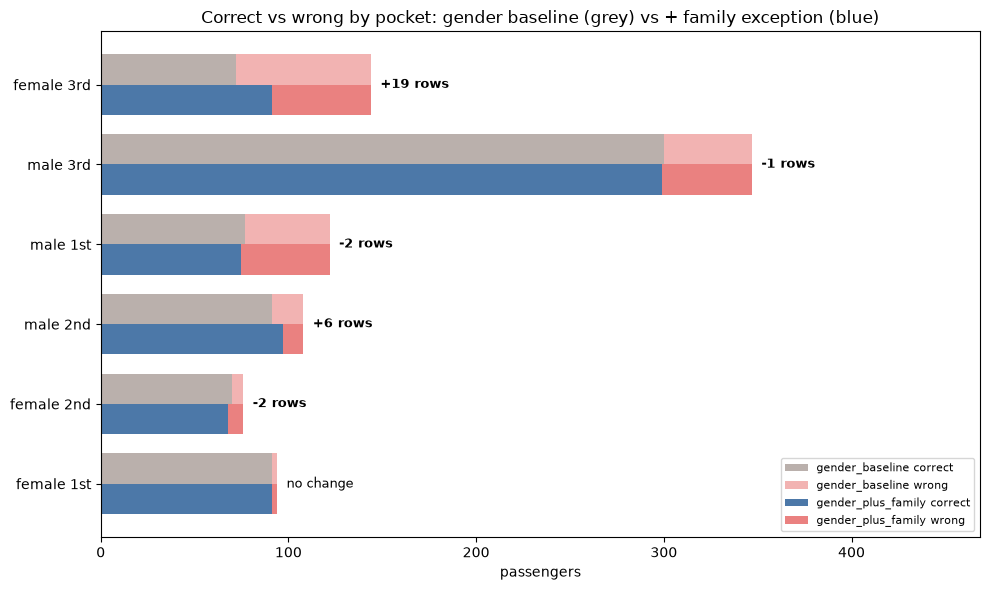

net rows across all pockets: +20


In [7]:
# correct vs wrong per pocket, the two models side by side
fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(comparison))
height = 0.38
for offset, name, shade in [(-height / 2, "gender_baseline", "#bab0ac"),
                            (height / 2, "gender_plus_family", "#4c78a8")]:
    ax.barh(positions + offset, comparison[f"{name}_correct"], height, color=shade,
            label=f"{name} correct")
    ax.barh(positions + offset, comparison[f"{name}_wrong"], height,
            left=comparison[f"{name}_correct"], color="#e45756", alpha=0.75 if offset > 0 else 0.45,
            label=f"{name} wrong")
for i, row in enumerate(comparison.itertuples()):
    change = "no change" if row.net_rows == 0 else f"{row.net_rows:+d} rows"
    ax.text(row.n + 5, i, change, va="center", fontsize=9,
            fontweight="bold" if row.net_rows else "normal")
ax.set_yticks(positions, comparison.index)
ax.invert_yaxis()
ax.set_xlim(0, comparison["n"].max() * 1.35)
ax.set_xlabel("passengers")
ax.set_title("Correct vs wrong by pocket: gender baseline (grey) vs + family exception (blue)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"net rows across all pockets: {comparison['net_rows'].sum():+d}")

## Weighting by test-set exposure

Errors counted on `train.csv` are not the thing being scored. A pocket is only worth what it is
worth *on the 418 test rows* -- and the pockets are not the same size in both files.

In [8]:
test_df = pd.read_csv("data/test.csv")
test_group = test_df["Sex"] + " " + test_df["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})

exposure = pd.DataFrame({
    "train_n": summary["n"],
    "rule_accuracy": summary["accuracy"],
    "train_errors": summary["wrong"],
})
exposure["test_n"] = test_group.value_counts()
exposure["test_share"] = (exposure["test_n"] / len(test_df)).round(3)
# the error rate is assumed to carry over; the pocket sizes do not
exposure["expected_test_errors"] = (exposure["test_n"] * (1 - exposure["rule_accuracy"])).round(1)
# net rows on the test set from replacing the rule inside a pocket with a predictor of accuracy X
for target in (0.70, 0.80):
    exposure[f"net@{target:.0%}"] = (
        (target - exposure["rule_accuracy"]) * exposure["test_n"]
    ).round(1)
exposure = exposure.sort_values("expected_test_errors", ascending=False)

print(f"expected test errors summed: {exposure['expected_test_errors'].sum():.0f}")
print(f"the baseline actually scored 0.76555 = 320/418, so 98 real errors -- the estimate is close")
print("rows needed for 0.80 on the leaderboard: +14")
exposure

expected test errors summed: 91
the baseline actually scored 0.76555 = 320/418, so 98 real errors -- the estimate is close
rows needed for 0.80 on the leaderboard: +14


,train_n,rule_accuracy,train_errors,test_n,test_share,expected_test_errors,net@70%,net@80%
group,,,,,,,,
female 3rd,144,0.500000,72,72,0.172,36.0,14.4,21.6
male 1st,122,0.631148,45,57,0.136,21.0,3.9,9.6
male 3rd,347,0.864553,47,146,0.349,19.8,-24.0,-9.4
male 2nd,108,0.842593,17,63,0.151,9.9,-9.0,-2.7
female 2nd,76,0.921053,6,30,0.072,2.4,-6.6,-3.6
female 1st,94,0.968085,3,50,0.120,1.6,-13.4,-8.4


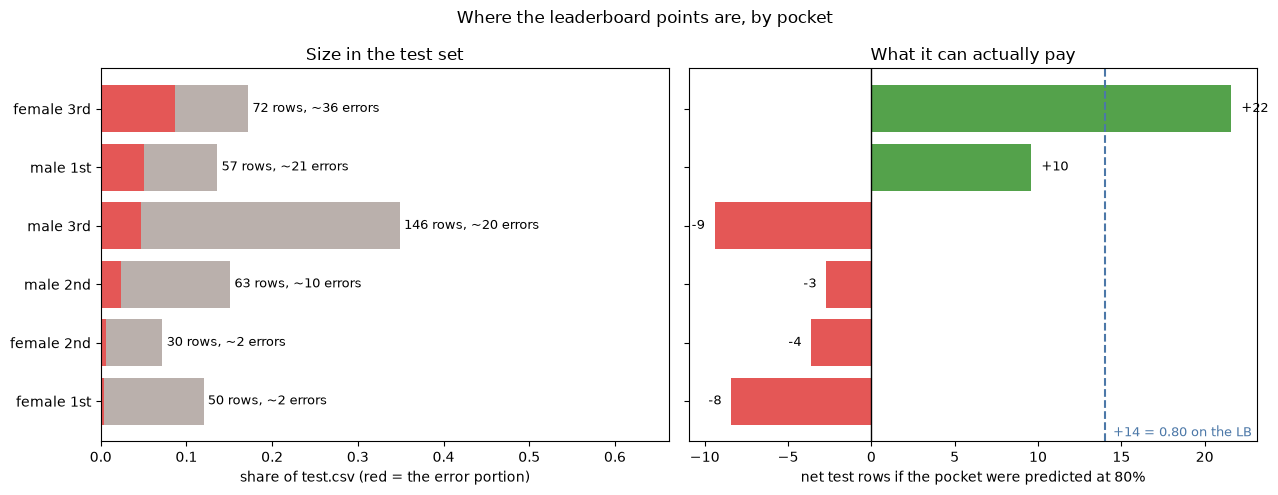

In [9]:
# two views side by side: how big the pocket is in the test set, and what it can actually pay
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))
positions = np.arange(len(exposure))

left.barh(positions, exposure["test_share"], color="#bab0ac")
left.barh(positions, exposure["expected_test_errors"] / len(test_df), color="#e45756")
for i, row in enumerate(exposure.itertuples()):
    left.text(row.test_share + 0.005, i, f"{row.test_n} rows, ~{row.expected_test_errors:.0f} errors",
              va="center", fontsize=9)
left.set_yticks(positions, exposure.index)
left.invert_yaxis()
left.set_xlim(0, exposure["test_share"].max() * 1.9)
left.set_xlabel("share of test.csv (red = the error portion)")
left.set_title("Size in the test set")

colours = ["#54a24b" if v > 0 else "#e45756" for v in exposure["net@80%"]]
right.barh(positions, exposure["net@80%"], color=colours)
right.axvline(0, color="black", linewidth=1)
right.axvline(14, color="#4c78a8", linestyle="--", linewidth=1.5)
right.text(14.5, len(exposure) - 0.4, "+14 = 0.80 on the LB", fontsize=9, color="#4c78a8")
for i, row in enumerate(exposure.itertuples()):
    right.text(row._8 + (0.6 if row._8 > 0 else -0.6), i, f"{row._8:+.0f}",
               va="center", ha="left" if row._8 > 0 else "right", fontsize=9)
right.set_yticks(positions, [])
right.invert_yaxis()
right.set_xlabel("net test rows if the pocket were predicted at 80%")
right.set_title("What it can actually pay")
plt.suptitle("Where the leaderboard points are, by pocket")
plt.tight_layout()
plt.show()

## How to read this

- **`wrong`** is the ceiling for a pocket: fix every error there and that's what you gain. Two
  pockets hold most of it, and they need opposite corrections -- 3rd-class women who died, and
  1st-class men who survived.
- **`rule_accuracy`** is the bar you have to clear inside that pocket. It is not zero -- the rule
  already gets 86.5% of 3rd-class men right, so a replacement that is 80% accurate there *loses*
  you rows. This is the number people forget.
- **`net@X%`** is what a predictor of accuracy X inside the pocket would gain: `X x n - correct`.
  Negative means it would be worse than leaving that pocket alone.
- **`net@100%`** equals `wrong`: the ceiling, what a perfect oracle for that pocket would buy.
- Prefer pockets where `rule_accuracy` is near 0.5 -- there the rule is guessing, so almost any real
  signal pays. Pockets already at 0.9+ demand near-perfect precision just to break even.
- The standard error on any of these counts is roughly `sqrt(n)`, so a pocket of 76 rows cannot
  demonstrate a gain smaller than about 9 rows no matter how good the idea is.